# Reinforcement learning on GSM8K

The model gets a grade-school word problem, answers it, and a **reward function checks the
arithmetic**. Answers that are right get reinforced. Nothing labels *how* to solve the
problem — only whether the final number was correct.

That is the whole appeal of RL over supervised fine-tuning: you need a way to *recognise* a
good answer, not a worked example of one. Here recognising it is a regex and a string
comparison, about ten lines, so the reward is fully verifiable and there is nothing to
install for it.

**How GRPO works.** For each problem you sample a *group* of answers and compare them to
each other:

```
advantage = this answer's reward - the group's mean
```

An answer above its group's mean gets reinforced, one below it gets discouraged, and a group
whose answers all scored alike contributes nothing. The reward *level* never reaches the
gradient, only the spread inside a group. That is what lets the method work with no value
network and no critic: the group is the baseline.

In [02](02_sft_banking77.ipynb) you had the right answer for every row and taught the model
to copy it. Here you only have a way to check one.

This is the shortest of the training notebooks. Ten steps, about fifteen minutes.

## Setup

One dependency list, shared by every notebook in this folder. Run this from its own
directory so the relative paths resolve.

In [1]:
try:
    import pip
except ImportError:
    import ensurepip
    ensurepip.bootstrap()

%pip install --quiet --upgrade -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
from getpass import getpass

if not os.environ.get("CRUSOE_API_KEY"):
    os.environ["CRUSOE_API_KEY"] = getpass("Crusoe API key: ")

os.environ.setdefault("CRUSOE_BASE_URL", "https://api.intelligence.crusoecloud.com")
print("endpoint:", os.environ["CRUSOE_BASE_URL"])

## The knobs

`TEMPERATURE = 1.0` is a requirement rather than a preference. The `importance_sampling`
loss reweights each token by the ratio between what the trainer believes now and what the
sampler believed when it generated that token. The trainer computes its side at temperature
1.0, so sampling at anything else compares two different distributions and quietly biases
every gradient. The run still completes. It just learns the wrong thing.

In [3]:
MODEL = "Qwen/Qwen3.5-9B-Base"

LORA_RANK = 32
LEARNING_RATE = 4e-5
STEPS = 10

PROBLEMS_PER_STEP = 16   # distinct problems per step
GROUP_SIZE = 8           # answers sampled per problem
MAX_RESPONSE_TOKENS = 256
TEMPERATURE = 1.0
TOP_P = 0.95
TOP_K = 20

EVAL_PROBLEMS = 256      # the held-out test split, scored before and after
EVAL_SAMPLES = 8         # samples per eval problem
EVAL_EVERY = 3           # score the held-out set every N steps, and at the end

## The reward

GSM8K ships a worked solution ending in `#### <number>`. `prepare_data.py` keeps just that
number as the label. We ask for the answer inside `\boxed{}` and compare the two strings.

In [4]:
import re

#: The last one, not the first: a model that reasons aloud often boxes an intermediate value
#: before the answer it settles on.
BOXED = re.compile(r"\\boxed\{([^}]*)\}")


def grade(response, expected):
    """1.0 only if the boxed number matches the reference exactly."""
    found = BOXED.findall(response)
    if not found:
        return 0.0
    return float(found[-1].replace(",", "").strip() == expected.strip())


for answer in (r"so the total is \boxed{72}", r"\boxed{18} no wait, \boxed{72}",
               r"the answer is 72", r"\boxed{71}"):
    print(f"  {grade(answer, '72'):.0f}   {answer!r}")

  1   'so the total is \\boxed{72}'
  1   '\\boxed{18} no wait, \\boxed{72}'
  0   'the answer is 72'
  0   '\\boxed{71}'


## The problems

Built from the public `openai/gsm8k`, pinned by commit and checked by md5. `test.jsonl` comes from GSM8K's own test split, so the before and
after numbers are measured on problems the loop never trains on.

In [5]:
import json
from pathlib import Path

from prepare_data import ensure_gsm8k

EXAMPLE_DATA = Path("data/gsm8k")
# To train on your own problems, point this at a directory holding train.jsonl and test.jsonl.
DATA = EXAMPLE_DATA

if DATA == EXAMPLE_DATA:
    # Pulls the rows from the public upstream dataset and checks each file's md5. Already
    # built means this is a no-op.
    ensure_gsm8k()


def load_rows(name):
    with open(DATA / name, encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


train_rows = load_rows("train.jsonl")
test_rows = load_rows("test.jsonl")[:EVAL_PROBLEMS]

example = train_rows[0]
print("problem:", example["input"][0]["content"][:220])
print("answer :", example["label"])
print(f"\n{len(train_rows)} training problems, {len(test_rows)} test")

  ok       train.jsonl              512 rows  57f073ff7d52e1980bdae6617494eb7d
  ok       test.jsonl               256 rows  0c4c50f2da06a98a4aa0ee377e8ce2f6
gsm8k already built and verified
problem: The state of Virginia had 3.79 inches of rain in March, 4.5 inches of rain in April, 3.95 inches of rain in May, 3.09 inches of rain in June and 4.67 inches in July.  What is the average rainfall amount, in inches, in Vi
answer : 4

512 training problems, 256 test


## The session

Constructing the `ServiceClient` is what waits for your GPUs: it provisions the session and
does not return until it is ready, which is minutes on a cold start. Interrupting it releases
the session.

In [6]:
from crusoe_mill import (
    SamplingBaseModelConfig,
    ServiceClient,
    ServiceConfig,
    TrainingBaseModelConfig,
)
from tinker import types
from transformers import AutoTokenizer

client = ServiceClient(
    service_config=ServiceConfig(
        # One replica each. Raise num_replicas on the sampling row to generate rollouts faster.
        training_client_base_models=[TrainingBaseModelConfig(base_model=MODEL, num_replicas=1)],
        sampling_client_base_models=[SamplingBaseModelConfig(base_model=MODEL, num_replicas=1)],
    ),
)

training_client = client.create_lora_training_client(
    base_model=MODEL,
    rank=LORA_RANK,
    train_attn=True,
    train_mlp=True,
    train_unembed=False,
    seed=0,
)
tokenizer = AutoTokenizer.from_pretrained(MODEL)
print("training client ready")

[2026-09-29 01:34:05 crusoe_mill._progress INFO] tinker session msess_4e61600c647143a1ae9dbd22a0416922 created; provisioning Qwen/Qwen3.5-9B-Base
[2026-09-29 01:34:05 crusoe_mill.service_client INFO] ServiceClient initialized for session msess_4e61600c647143a1ae9dbd22a0416922
[2026-09-29 01:34:06 crusoe_mill._progress INFO] provisioning — 3s elapsed (session msess_4e61600c647143a1ae9dbd22a0416922; ^C releases it)
[2026-09-29 01:35:17 crusoe_mill._progress INFO] provisioning — 74s elapsed (session msess_4e61600c647143a1ae9dbd22a0416922; ^C releases it)
[2026-09-29 01:36:18 crusoe_mill._progress INFO] provisioning — 135s elapsed (session msess_4e61600c647143a1ae9dbd22a0416922; ^C releases it)


training client ready


## Prompting, sampling, scoring

`enable_thinking=False` closes the reasoning block in the chat template. Left open, Qwen can
spend the whole 256-token budget thinking and never emit a `\boxed{}` at all, which scores
zero for a reason that has nothing to do with arithmetic.

We prompt the base checkpoint through its chat template for simplicity. That starts it fairly
high, around 80% on the held-out split, so the gain below is real but modest. Prompting it as
plain text with one worked example instead starts it lower, near 75%, and leaves more room for
a visible learning curve.

In [7]:
import numpy as np

INSTRUCTION = r"Give the final number, with no units, inside \boxed{}."


def render(question):
    return types.ModelInput.from_ints(tokenizer.apply_chat_template(
        [{"role": "user", "content": f"{question}\n\n{INSTRUCTION}"}],
        add_generation_prompt=True, tokenize=True, return_dict=False, enable_thinking=False))


def sample_and_score(sampler, rows, group_size):
    """Returns the prompts, the sampled groups, and one score per sample."""
    prompts = [render(row["input"][0]["content"]) for row in rows]
    params = types.SamplingParams(max_tokens=MAX_RESPONSE_TOKENS, temperature=TEMPERATURE,
                                  top_p=TOP_P, top_k=TOP_K)

    # one request per sample, not one per group
    futures = [sampler.sample(prompt=p, sampling_params=params, num_samples=1)
               for p in prompts for _ in range(group_size)]
    flat = [future.result() for future in futures]

    class _Group:
        """Regroup the single-sample responses so everything downstream is unchanged."""
        __slots__ = ("sequences",)

        def __init__(self, sequences):
            self.sequences = sequences

    results = [_Group([flat[i * group_size + j].sequences[0] for j in range(group_size)])
               for i in range(len(prompts))]

    scores = []
    for row, result in zip(rows, results):
        for sequence in result.sequences:
            answer = tokenizer.decode(sequence.tokens, skip_special_tokens=True)
            scores.append(grade(answer, row["label"]))
    return prompts, results, scores


def measure(sampler, rows, samples):
    """Mean reward over a fixed set of rows, so two calls are directly comparable."""
    _, _, scores = sample_and_score(sampler, rows, samples)
    return float(np.mean(scores))

## Advantages and datums

The advantage is each sample's reward minus its **group's** mean. Only within-group spread
survives, so a problem the model always gets right and one it always gets wrong both
contribute nothing - which is why a group that scored uniformly is dropped rather than
trained on.

Prompt positions get advantage 0. That is what masks them out of the policy gradient; the
RL losses take no separate weights mask.

In [8]:
def group_advantages(scores, group_size):
    """Reward minus the group mean. Uniform groups come out all-zero and carry no gradient."""
    rewards = np.asarray(scores, dtype=float).reshape(-1, group_size)
    return (rewards - rewards.mean(axis=1, keepdims=True)).ravel().tolist()


def build_datums(prompts, results, advantages):
    staged, index = [], 0
    for prompt, result in zip(prompts, results):
        prompt_ids = prompt.to_ints()
        for sequence in result.sequences:
            advantage, index = advantages[index], index + 1
            if advantage == 0.0:
                continue
            response_ids = list(sequence.tokens)
            # The importance-sampling loss needs the sampler's own logprob for every token.
            if sequence.logprobs is None or len(sequence.logprobs) != len(response_ids):
                raise ValueError(f"expected {len(response_ids)} sampler logprobs, "
                                 f"got {None if sequence.logprobs is None else len(sequence.logprobs)}")
            all_ids = prompt_ids + response_ids
            model_input = types.ModelInput.from_ints(all_ids[:-1])
            targets = np.asarray(all_ids[1:], dtype=np.int64)
            advantage_row = np.asarray([0.0] * (len(prompt_ids) - 1) + [advantage] * len(response_ids),
                                       dtype=np.float32)
            logprobs = np.asarray([0.0] * (len(prompt_ids) - 1) + list(sequence.logprobs),
                                  dtype=np.float32)
            assert model_input.length == len(targets) == len(advantage_row) == len(logprobs)
            staged.append((model_input, targets, advantage_row, logprobs))

    # The loss is a sum, so scale to a per-token mean. Not optional: without it an identical
    # learning rate steps roughly batch-many times harder.
    scored_tokens = sum(int(np.count_nonzero(row[2])) for row in staged)
    datums = []
    for model_input, targets, advantage_row, logprobs in staged:
        if scored_tokens:
            advantage_row = advantage_row / float(scored_tokens)
        datums.append(types.Datum(model_input=model_input, loss_fn_inputs={
            "target_tokens": types.TensorData.from_numpy(targets),
            "advantages": types.TensorData.from_numpy(advantage_row),
            "logprobs": types.TensorData.from_numpy(logprobs),
        }))
    return datums

## The loop

One `forward_backward` and one `optim_step` per iteration, then the new weights are
published so the next step samples from the policy it just trained.

`reward` is the mean over the 16 problems drawn for *that* step. It costs nothing, because
those samples are generated for training anyway, but it is measured on a different set of
problems each time, so expect it to bounce. The number that settles the question is the
before-and-after on the held-out test split.

In [9]:
import random
import time

sampler = training_client.save_weights_and_get_sampling_client()

order = list(range(len(train_rows)))
random.Random(0).shuffle(order)

print("before training")
before = measure(sampler, test_rows, EVAL_SAMPLES)
print(f"  test {before:.1%} of {len(test_rows)} problems")
history = [{"step": 0, "test": before}]
batch_history = []

for step in range(STEPS):
    started = time.perf_counter()

    picked = [train_rows[order[(step * PROBLEMS_PER_STEP + i) % len(order)]]
              for i in range(PROBLEMS_PER_STEP)]
    prompts, results, scores = sample_and_score(sampler, picked, GROUP_SIZE)
    datums = build_datums(prompts, results, group_advantages(scores, GROUP_SIZE))

    if datums:
        forward_backward = training_client.forward_backward(datums, "importance_sampling")
        optimizer = training_client.optim_step(types.AdamParams(
            learning_rate=LEARNING_RATE, beta1=0.9, beta2=0.95, eps=1e-8))
        # Optimizer first: a large batch can be sent in several parts, and the step completes only
        # once all of them have arrived, so waiting on it first guarantees the whole batch is in.
        optimizer.result()
        forward_backward.result()

        # One call rather than save-then-create: the loop samples from the new weights
        # immediately and never needs the checkpoint path.
        sampler = training_client.save_weights_and_get_sampling_client()

    batch = float(np.mean(scores))
    batch_history.append({"step": step + 1, "reward": batch})
    print(f"step {step + 1:2d}/{STEPS}  batch {batch:.1%}  "
          f"datums {len(datums):4d}/{PROBLEMS_PER_STEP * GROUP_SIZE}  "
          f"{time.perf_counter() - started:.0f}s")

    # The curve is the held-out set, not the batch above. Same problems every time, so it
    # moves only when the policy does; the batch is 16 fresh problems and mostly draw noise.
    if (step + 1) % EVAL_EVERY == 0 or step + 1 == STEPS:
        accuracy = measure(sampler, test_rows, EVAL_SAMPLES)
        history.append({"step": step + 1, "test": accuracy})
        print(f"           test {accuracy:.1%} of {len(test_rows)} problems")

after = history[-1]["test"]

before training
  test 77.6% of 256 problems
step  1/10  batch 82.8%  datums   64/128  36s
step  2/10  batch 85.9%  datums   48/128  13s
step  3/10  batch 85.9%  datums   32/128  8s
           test 89.3% of 256 problems
step  4/10  batch 80.5%  datums   48/128  9s
step  5/10  batch 94.5%  datums   32/128  8s
step  6/10  batch 86.7%  datums   64/128  8s
           test 91.6% of 256 problems
step  7/10  batch 85.9%  datums   32/128  8s
step  8/10  batch 96.1%  datums   24/128  8s
step  9/10  batch 85.2%  datums   40/128  8s
           test 92.0% of 256 problems
step 10/10  batch 83.6%  datums   40/128  10s
           test 94.0% of 256 problems


## Did it work?

In [10]:
print(f"{'before':10} {before:>7.1%}")
print(f"{'after':10} {after:>7.1%}")
print(f"{'change':10} {after - before:>+7.1%}")

before       77.6%
after        94.0%
change      +16.5%


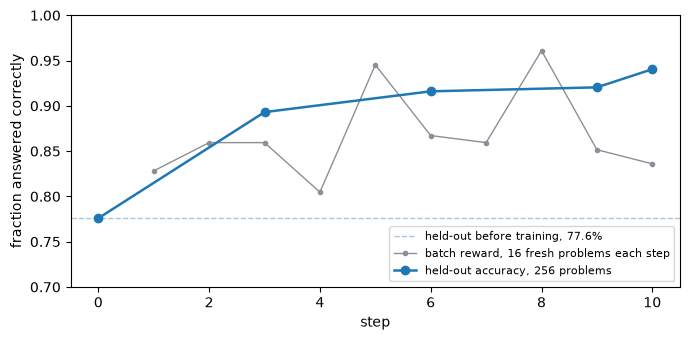

In [12]:
import matplotlib.pyplot as plt

figure, axis = plt.subplots(figsize=(7, 3.5))
axis.axhline(before, linestyle="--", linewidth=1, color="C0", alpha=0.4,
             label=f"held-out before training, {before:.1%}")
axis.plot([h["step"] for h in batch_history], [h["reward"] for h in batch_history],
          marker=".", linewidth=1, color="#8a8f98",
          label=f"batch reward, {PROBLEMS_PER_STEP} fresh problems each step")
axis.plot([h["step"] for h in history], [h["test"] for h in history],
          marker="o", linewidth=1.8, color="C0",
          label=f"held-out accuracy, {len(test_rows)} problems")
axis.set_xlabel("step")
axis.set_ylabel("fraction answered correctly")
axis.set_ylim(0.70, 1)
axis.legend(loc="lower right", fontsize=8)
figure.tight_layout()

### Reading the result

**Up** means it worked: the model is solving problems it previously got wrong.

**`datums` near the full batch** means most groups are mixed, which is the healthy case —
every group with spread contributes gradient. **`datums 0` on most steps** means the reward
is saturated in one direction: the model either always succeeds (raise the difficulty) or
never does (it cannot bootstrap from a problem it never solves).

**Individual steps go down, and that is expected.** Each step draws 16 new problems, so a
dip usually means that step drew harder ones rather than that the model got worse. Read the
trend across the run and the held-out before-and-after, not adjacent steps. On a longer run
where the effect is smaller, scoring one fixed held-out set every step is worth the extra
sampling; over ten steps with a gain this size, it is not.

In [13]:
client.close()
print("session closed")

session closed


## What to change next

The loop is task-agnostic. Everything specific to GSM8K is in two places: the rows in
`DATA` (set it in the data cell to a directory of your own `train.jsonl` and `test.jsonl`, one
`{"input": [...messages...], "label": ...}` object per line), and the `grade` function. Swap the reward for your own — a unit-test runner,
a schema validator, a second model as judge — and the rest is unchanged.

Compared with notebook 02's supervised fine-tuning, the difference is what you must supply:
SFT needs the right answer written out for every example, RL only needs a way to tell
whether an answer is right.